29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training CNN model...
Epoch 1/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 31s 32ms/step - accuracy: 0.7046 - loss: 0.8235 - val_accuracy: 0.8534 - val_loss: 0.3993
Epoch 2/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 28s 30ms/step - accuracy: 0.8478 - loss: 0.4142 - val_accuracy: 0.8819 - val_loss: 0.3304
Epoch 3/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 29s 31ms/step - accuracy: 0.8722 - loss: 0.3548 - val_accuracy: 0.8805 - val_loss: 0.3250
Epoch 4/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 28s 30ms/step - accuracy: 0.8862 - loss: 0.3139 - val_accuracy: 0.8941 - val_loss: 0.2919
Epoch 5/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 30s 32ms/step - accuracy: 0.8936 - loss: 0.2922 - val_accuracy: 0.8820 - val_loss: 0.3028


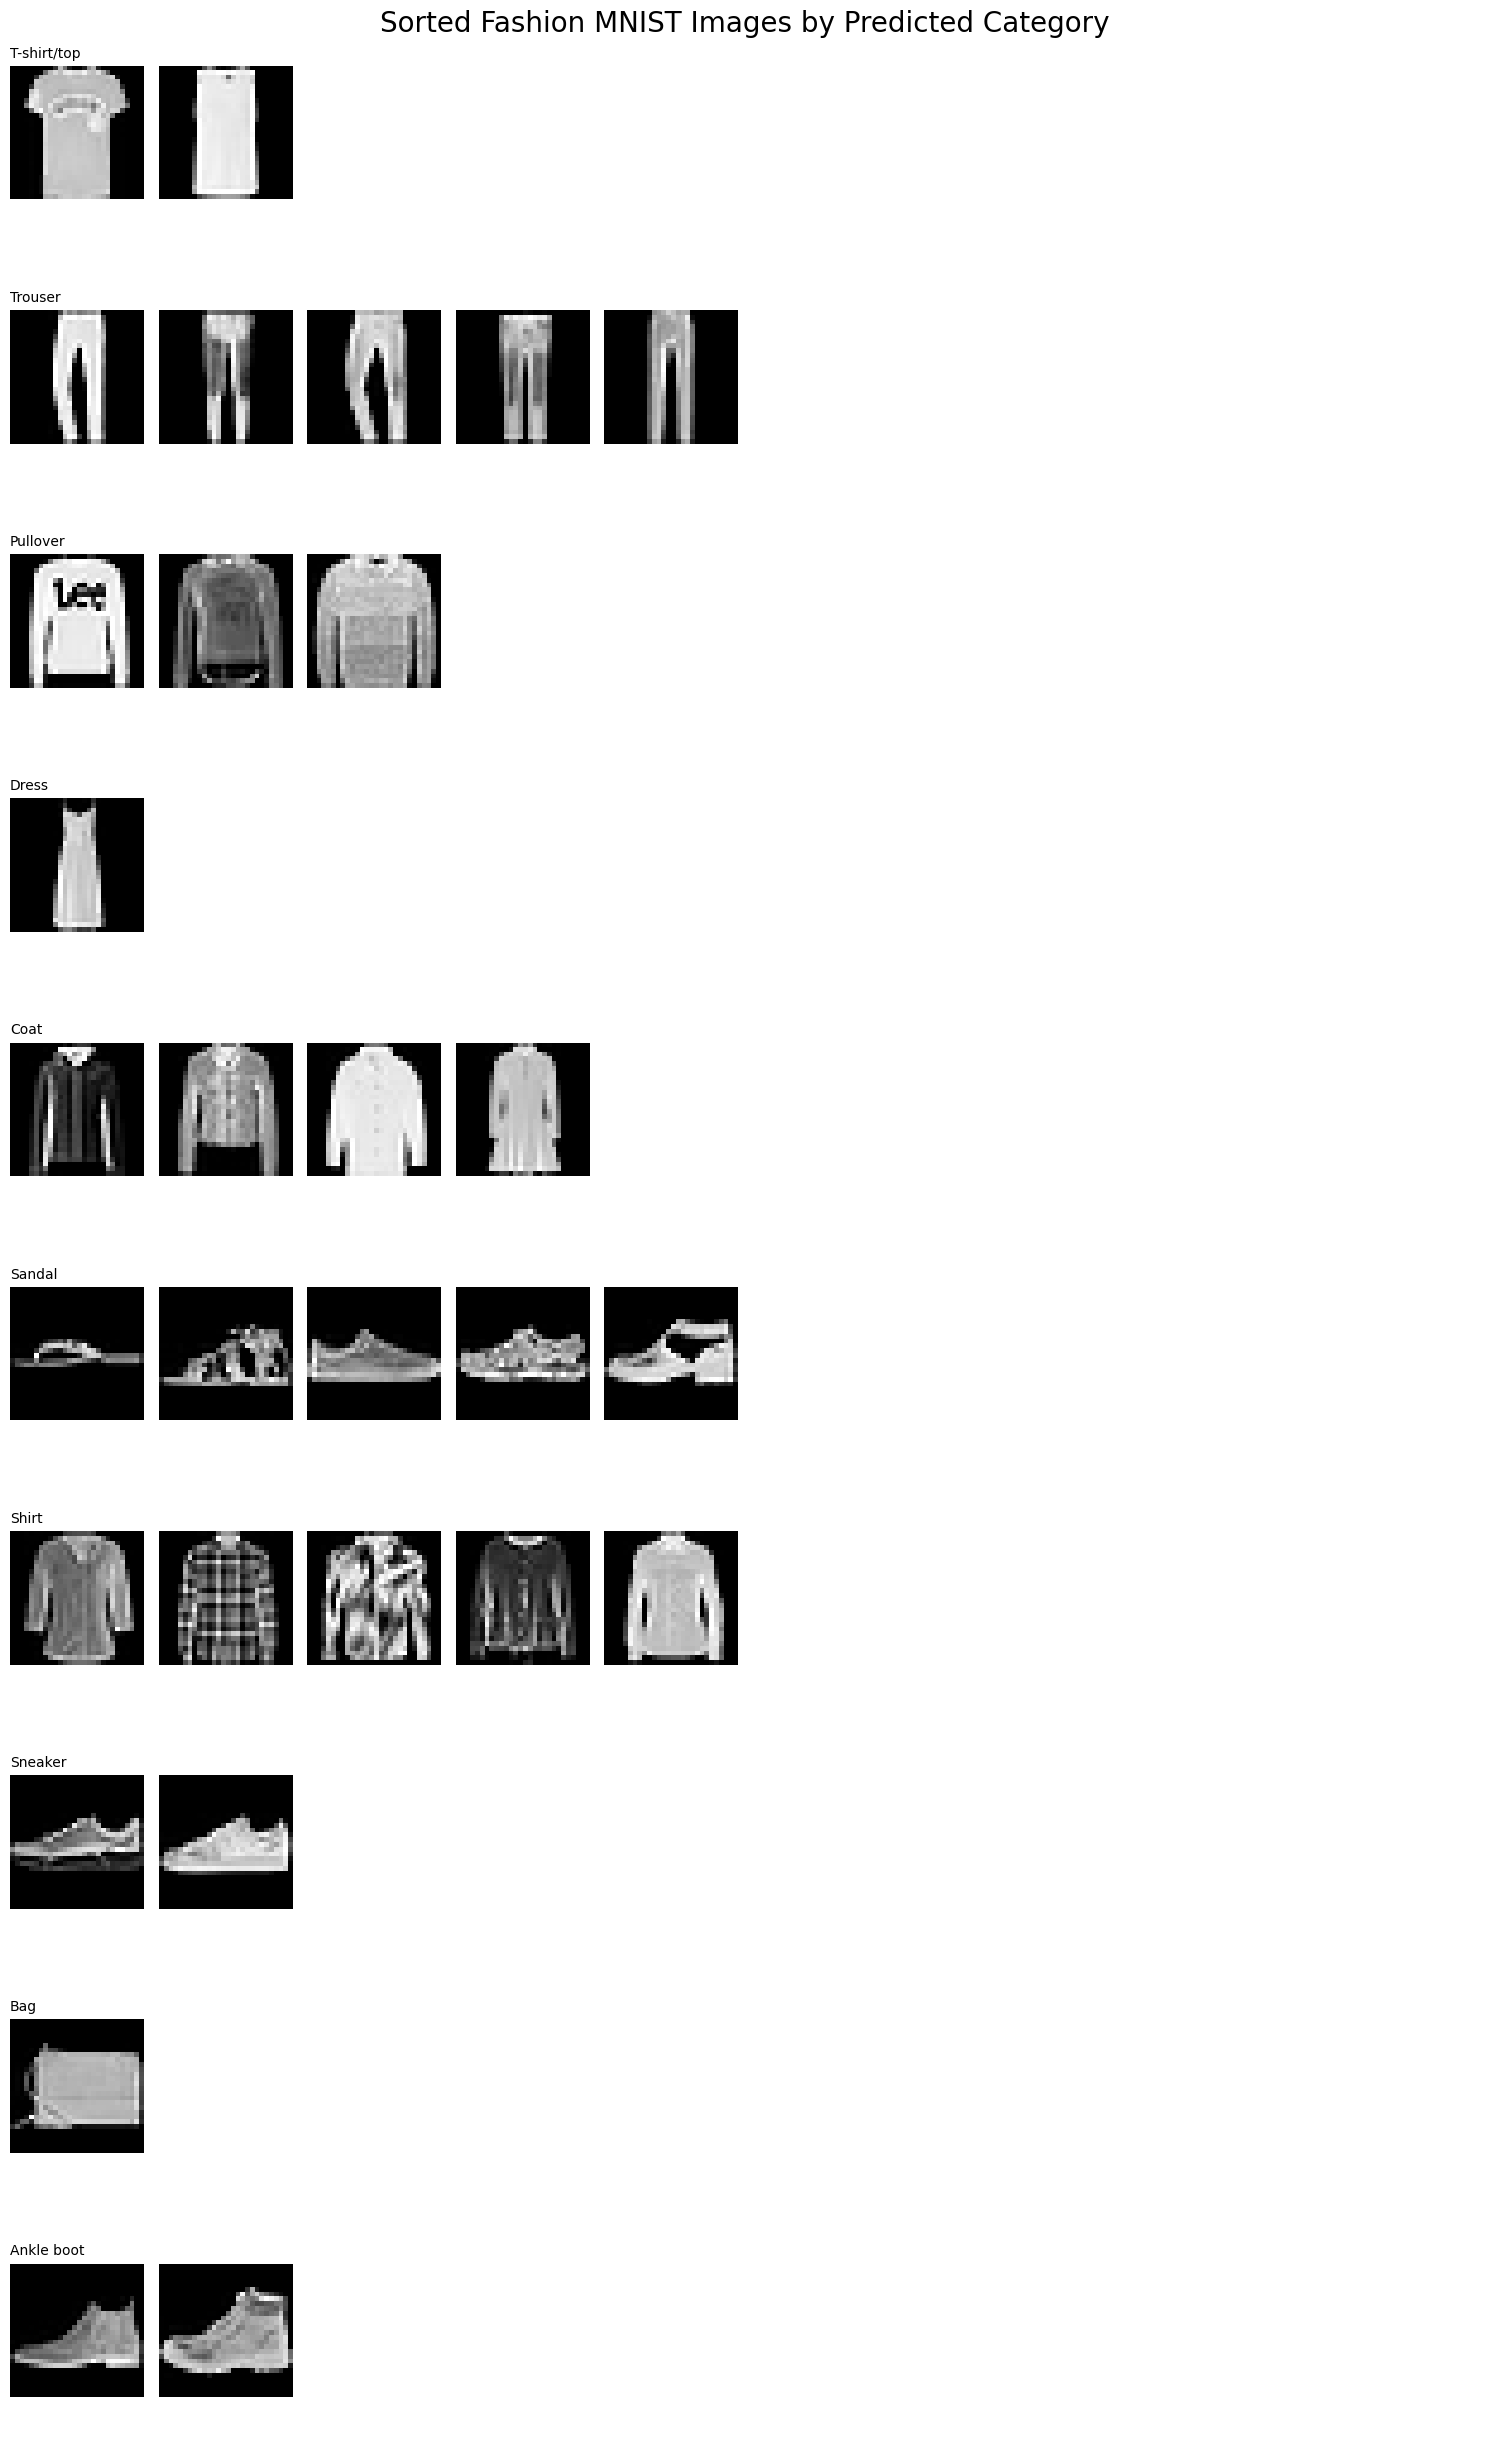

In [1]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical
import numpy as np
import matplotlib.pyplot as plt

# Load Fashion MNIST dataset (clothing items only)
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

# Expand dimensions to add channel=1 for grayscale images
x_train = np.expand_dims(x_train, -1).astype("float32") / 255.0
x_test = np.expand_dims(x_test, -1).astype("float32") / 255.0

# One-hot encode labels (10 classes)
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# Labels for Fashion MNIST
labels = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
          "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

# Build CNN model
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    MaxPooling2D((2,2)),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

print("Training CNN model...")
history = model.fit(
    x_train, y_train,
    epochs=5,
    batch_size=64,
    validation_data=(x_test, y_test)
)

# Predict and display sorted images by class
num_images = 30
sorted_images = {label: [] for label in labels}

for i in range(num_images):
    img = x_test[i]
    img_array = np.expand_dims(img, axis=0)
    prediction = model.predict(img_array, verbose=0)
    class_index = np.argmax(prediction)
    label = labels[class_index]
    sorted_images[label].append(img.squeeze())

fig, axes = plt.subplots(len(sorted_images), 10, figsize=(15, 25))
fig.suptitle("Sorted Fashion MNIST Images by Predicted Category", fontsize=20)

for row, (label, images) in enumerate(sorted_images.items()):
    for col in range(10):
        ax = axes[row, col]
        ax.axis("off")
        if col < len(images):
            ax.imshow(images[col], cmap='gray')
        if col == 0:
            ax.set_title(label, fontsize=10, loc="left")

plt.tight_layout()
plt.show()
